# Selección de variables estable

## Qué responde este notebook

¿Qué variables necesitan los modelos? Las 34 que usan hoy salieron de
[`3.2_seleccion_features.ipynb`](3.2_seleccion_features.ipynb), con una selección que tiene tres
debilidades registradas en [`docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md): midió la importancia
con MAE, que premia la mediana; usó 2024-2025 como validación, los mismos años que la etapa 4 usa
como prueba; y su regla (las 15 más importantes de cada resultado) es inestable: con el dato de
alineaciones corregido daría otra lista.

Aquí se repite la selección con la regla de
[`docs/decisions/0005-seleccion-de-variables.md`](../../../docs/decisions/0005-seleccion-de-variables.md),
fijada antes de ver los resultados:

1. **Las mismas candidatas de 3.2**, con la alineación unificada (que sí tiene dato en 2025) y una
   nueva: el total implícito de puntos del equipo según las líneas de apuestas
   ([`2.3_eda_general.ipynb`](2.3_eda_general.ipynb)).
2. **Un orden de las candidatas que no toca la validación**: eliminación recursiva con importancia
   por permutación, medida con la métrica principal de cada resultado (RMSE o deviance de Poisson,
   ADR 0004), repetida en 10 submuestras.
3. **El tamaño del conjunto se decide en validación (2022-2023)**: el conjunto más chico que no sea
   peor que el mejor ni que las 34 actuales. La prueba (2024-2025) solo se reporta al final.

Las variables se definen en el [glosario](../../../docs/data/GLOSARIO_VARIABLES.md).

In [1]:
import sys
sys.path.insert(0, "../src")
import data, features, features_exploratorio, modeling, experimentos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 90)
sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

TARGETS = list(modeling.TARGETS)
CONFIG_ELEGIDA = {
    "receptions": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_yards": dict(max_depth=3, n_estimators=200, learning_rate=0.03),
    "receiving_tds": dict(objective="count:poisson", max_depth=3, n_estimators=200, learning_rate=0.08),
}

wr = features_exploratorio.construir_tabla_candidatas(range(2016, 2026))
numericas, categoricas = features_exploratorio.columnas_candidatas()
X, unidades = experimentos.codificar_candidatas(wr, numericas, categoricas)
ys = {t: wr[t] for t in TARGETS}
print(f"filas WR 2016-2025: {len(wr)} | candidatas: {len(unidades)} ({len(numericas)} numericas y "
      f"{len(categoricas)} categoricas) | columnas tras codificar las categoricas: {X.shape[1]}")

filas WR 2016-2025: 23610 | candidatas: 110 (107 numericas y 3 categoricas) | columnas tras codificar las categoricas: 126


## 1. Las candidatas, con un caso concreto

Son las de `3.2`: 21 estadísticas semanales del receptor, cada una en cuatro ventanas (promedio de
la temporada, de sus últimas 3 y 5 apariciones y de carrera), más su perfil, el contexto de equipo y
de partido, la volatilidad, los cambios de quarterback o de equipo y tres interacciones. La nueva es
el total implícito: con la línea del partido (`spread_line`, positiva cuando el local es favorito) y
el total de puntos esperado (`total_line`), el local espera anotar `(total + línea) / 2` y el
visitante `(total − línea) / 2`. Se conoce antes del partido.

Un caso: Ja'Marr Chase en la semana 17 de 2021.

In [2]:
calendario_2021 = data.cargar_calendario([2021])
fila = wr[(wr["player_display_name"] == "Ja'Marr Chase") & (wr["season"] == 2021) & (wr["week"] == 17)].iloc[0]
partido = calendario_2021[(calendario_2021["week"] == 17)
                          & ((calendario_2021["home_team"] == fila["team"]) | (calendario_2021["away_team"] == fila["team"]))].iloc[0]
es_local = partido["home_team"] == fila["team"]
print(f"{partido['away_team']} en {partido['home_team']}: linea {partido['spread_line']:+.1f}, total {partido['total_line']:.1f}")
print(f"total implicito de {fila['team']} ({'local' if es_local else 'visitante'}): "
      f"({partido['total_line']:.1f} {'+' if es_local else '-'} {partido['spread_line']:.1f}) / 2 = {fila['total_implicito_equipo']:.2f}; "
      f"anoto {partido['home_score'] if es_local else partido['away_score']:.0f}")
print()
print(fila[["depth_team", "draft_pick", "edad", "receptions_last5_avg", "receptions_career_avg",
            "target_share_last5_avg", "total_implicito_equipo", "receptions", "receiving_yards"]].to_string())

tipo = pd.Series({u: "categorica" if u in categoricas
                  else "contexto" if u in features_exploratorio.CANDIDATAS_CONTEXTO else "estadistica en ventana"
                  for u in unidades})
print("\ncandidatas por tipo:")
print(tipo.value_counts().to_string())

KC en CIN: linea -3.5, total 51.0
total implicito de CIN (local): (51.0 + -3.5) / 2 = 23.75; anoto 34

depth_team                     1.0
draft_pick                     5.0
edad                      21.50308
receptions_last5_avg           4.2
receptions_career_avg     4.533333
target_share_last5_avg    0.195738
total_implicito_equipo       23.75
receptions                      11
receiving_yards                266

candidatas por tipo:
estadistica en ventana    84
contexto                  23
categorica                 3


**Lectura.** En ese partido Kansas City visitaba a Cincinnati como favorito por 3.5 puntos (línea de
−3.5) y se esperaban 51 puntos entre los dos. El total implícito de Cincinnati, como local, es
(51.0 − 3.5) / 2 = 23.75; anotó 34. Chase, titular (`depth_team` = 1) y quinta selección del draft,
venía de 4.2 recepciones por partido en sus últimas 5 apariciones. En total hay 110 candidatas: 84
estadísticas en ventana, 23 de contexto y 3 categóricas (126 columnas al codificar las categóricas).

## 2. Por qué una sola medición no alcanza

La importancia por permutación de una variable es cuánto empeora la predicción cuando se revuelven
sus valores entre filas. Si queda en el modelo otra variable casi igual, el modelo se apoya en ella
y la revuelta parece poco importante, aunque la información sea valiosa. Antes de medir nada se
revisa qué tan parecidas son las candidatas: correlación de Spearman entre las numéricas en
entrenamiento (2016-2021), y grupos por correlación media (enlace promedio). Esto no usa los
resultados a predecir.

In [3]:
entrenamiento = wr["season"].between(2016, 2021)
rho = wr.loc[entrenamiento, numericas].astype(float).corr(method="spearman").abs().fillna(0).to_numpy()
np.fill_diagonal(rho, 1)
arbol = linkage(squareform(1 - rho, checks=False), method="average")

filas = []
for corte in (0.2, 0.3, 0.4):
    grupos = pd.Series(fcluster(arbol, t=corte, criterion="distance"), index=numericas)
    tamanos = grupos.value_counts()
    filas.append({"correlacion media en el grupo, al menos": round(1 - corte, 1), "grupos": tamanos.size,
                  "variables en el grupo mas grande": int(tamanos.iloc[0]), "variables solas": int((tamanos == 1).sum())})
print(pd.DataFrame(filas).to_string(index=False))

grupos = pd.Series(fcluster(arbol, t=0.3, criterion="distance"), index=numericas)
mayor = grupos[grupos == grupos.value_counts().index[0]].index
print(f"\nel grupo mas grande con correlacion media de al menos 0.7 ({len(mayor)} variables):")
print(", ".join(mayor))

 correlacion media en el grupo, al menos  grupos  variables en el grupo mas grande  variables solas
                                     0.8      42                                44               28
                                     0.7      29                                53               14
                                     0.6      20                                55                7

el grupo mas grande con correlacion media de al menos 0.7 (53 variables):
receptions_season_avg, receptions_last3_avg, receptions_last5_avg, receptions_career_avg, targets_season_avg, targets_last3_avg, targets_last5_avg, targets_career_avg, receiving_yards_season_avg, receiving_yards_last3_avg, receiving_yards_last5_avg, receiving_yards_career_avg, receiving_air_yards_season_avg, receiving_air_yards_last3_avg, receiving_air_yards_last5_avg, receiving_air_yards_career_avg, receiving_yards_after_catch_season_avg, receiving_yards_after_catch_last3_avg, receiving_yards_after_catch_last5_avg, rec

**Lectura.** Casi todas las variables de volumen y participación forman un solo grupo: 53 variables
con correlación media de al menos 0.7, y todavía 44 si se exige 0.8. Están todas las ventanas de
recepciones, objetivos, yardas, yardas aéreas, yardas tras la recepción, primeros downs, jugadas de
10, 16 y 20 yardas o más, `target_share`, `air_yards_share`, `wopr` y puntos de fantasy. Entre ellas,
la importancia de una variable sola dice poco: si se revuelve, las otras 52 cubren casi lo mismo.
Por eso no sirve elegir con una sola medición, como hacía `3.2`.

## 3. Un orden estable: eliminación recursiva en 10 submuestras

La eliminación recursiva quita las variables más débiles por rondas y vuelve a medir la importancia
con las que quedan. Cuando sale una de dos variables casi iguales, la otra recupera su importancia
(Gregorutti, Michel y Saint-Pierre, 2017). La regla, del ADR 0005:

- Se ajusta el XGBoost elegido de cada resultado
  ([`4.4_ajuste_hiperparametros.ipynb`](4.4_ajuste_hiperparametros.ipynb)) con 2016-2019, y la
  importancia se mide en 2020-2021, como aumento relativo de la pérdida de la métrica principal.
  La validación 2022-2023 no se usa en esta sección.
- El conjunto será el mismo para los tres resultados, así que cada variable se califica con su
  mayor importancia entre los tres: sale solo lo que es débil para todos. En cada ronda sale el 10%
  con menor calificación (al menos una).
- Se repite en 10 submuestras, cada una con la mitad de las semanas de 2016-2019 elegidas al azar, y
  las variables se ordenan por la ronda promedio en que salen.

In [4]:
ajuste = wr["season"].between(2016, 2019)
evaluacion_interna = wr["season"].between(2020, 2021)
orden, rondas = experimentos.orden_estable(wr, X, ys, unidades, ajuste, evaluacion_interna, CONFIG_ELEGIDA,
                                           n_submuestras=10, fraccion_semanas=0.5, semilla=0)
n_rondas = int(rondas.max().max()) + 1
print(f"rondas por eliminacion: {n_rondas} (de {len(unidades)} candidatas a 1)")
orden.head(30).round(1)

rondas por eliminacion: 29 (de 110 candidatas a 1)


,ronda_promedio,ronda_minima,ronda_maxima
unidad,,,
receptions_career_avg,26.6,22,28
depth_team,22.3,20,24
target_share_last5_avg,22.2,13,28
receptions_season_avg,21.6,9,27
target_share_last3_avg,21.3,11,28
receptions_last3_avg,20.6,10,28
fantasy_points_ppr_last5_avg,19.0,10,28
total_implicito_equipo,18.9,18,21
receiving_yards_after_catch_career_avg,17.7,11,24


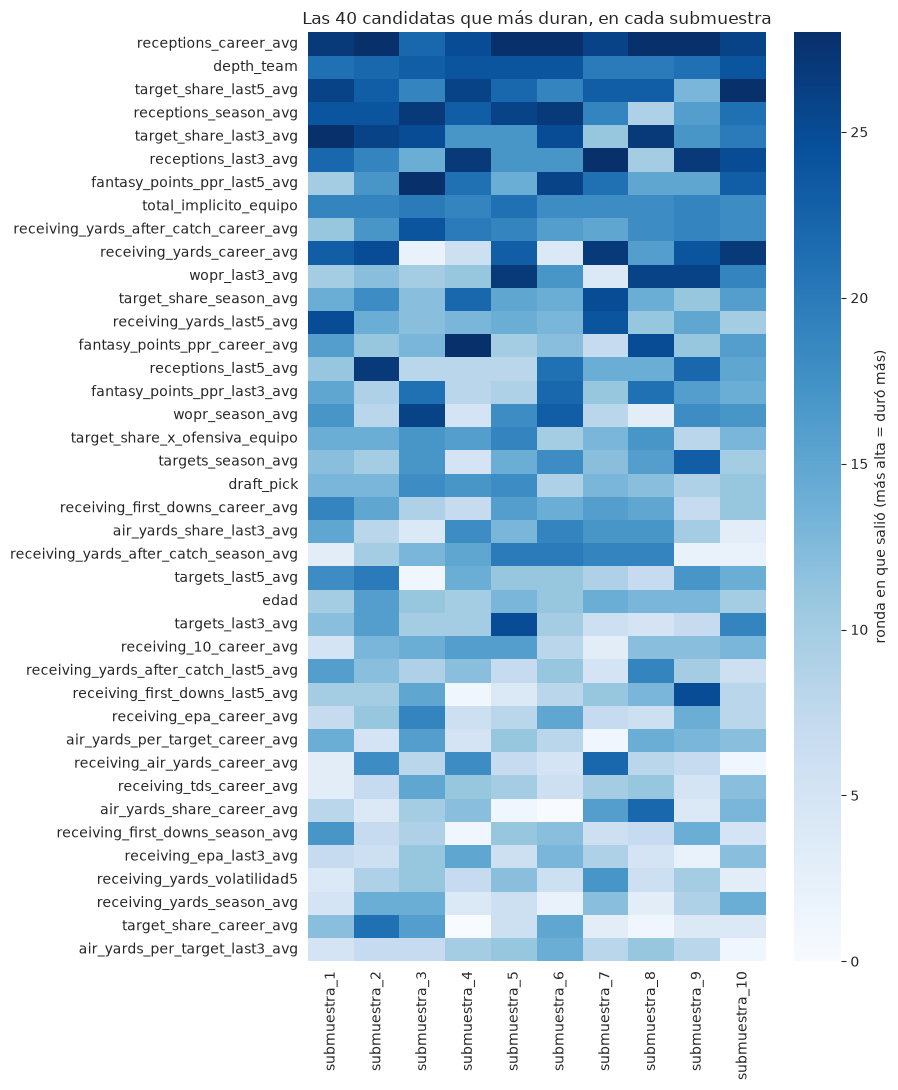

In [5]:
fig, ax = plt.subplots(figsize=(9, 11))
sns.heatmap(rondas.head(40), cmap="Blues", vmin=0, vmax=n_rondas - 1,
            cbar_kws={"label": "ronda en que salió (más alta = duró más)"}, ax=ax)
ax.set_title("Las 40 candidatas que más duran, en cada submuestra")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Lectura.** La eliminación tiene 29 rondas. Tres variables salen tarde en todas las submuestras:
`receptions_career_avg` (ronda promedio de 26.6, entre la 22 y la 28), `depth_team` (22.3, entre la
20 y la 24) y el total implícito (18.9, entre la 18 y la 21). Otras varían mucho de una submuestra a
otra: `receiving_yards_career_avg` sale entre la ronda 2 y la 27, y `wopr_last3_avg` entre la 4 y la
27. Es lo que se espera con variables casi iguales: en cada submuestra sobrevive una u otra, y por eso
se ordenan por la ronda promedio de las 10 y no por una sola eliminación.

## 4. ¿Cuántas variables hacen falta? Validación 2022-2023

Se ajustan con 2016-2021 los conjuntos de las 5, 10, 15, 20, 25, 30, 40, 50 y 75 primeras variables
del orden estable, todas las candidatas y las 34 actuales, y se predice la validación. La regla es de
no inferioridad (ADR 0005): se elige el conjunto más chico cuya pérdida, con 95% de confianza, no sea
más de 1% peor que la del mejor conjunto en ninguno de los tres resultados. La diferencia contra el
mejor se mide con el bootstrap de semanas de
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb) y se compara la cota
superior de su intervalo contra el margen.

**Por qué no basta un empate.** La primera versión de la regla tomaba como empate que el intervalo
de la diferencia incluyera cero, con el nivel ajustado por Bonferroni, y elegía el conjunto empatado
más chico. Un empate así solo dice que la diferencia no se distinguió del ruido, no que el conjunto
no sea peor: favorece a los conjuntos cuyas diferencias tienen más ruido, y el ajuste, al ensanchar
los intervalos, lo agrava. Esa regla elegía las 10 primeras variables. El problema se hizo visible al
reportar la prueba (sección 6), así que la corrección se fijó por principio y se aplica solo en
validación; la verificación sin ningún uso previo es la temporada 2026.

In [6]:
train_mask, val_mask, test_mask = experimentos.dividir_temporal(wr, range(2016, 2022), [2022, 2023], [2024, 2025])
actuales = features_exploratorio.VARIABLES_SELECCION_3_2
assert all(c in X.columns for c in actuales), "alguna de las 34 actuales no esta entre las candidatas"

conjuntos = {f"primeras {k}": list(orden.index[:k]) for k in (5, 10, 15, 20, 25, 30, 40, 50, 75)}
conjuntos["todas"] = list(orden.index)
conjuntos["34 actuales"] = list(actuales)
tamanos = {nombre: len(conjunto) for nombre, conjunto in conjuntos.items()}

def columnas_de(conjunto):
    return [c for u in conjunto for c in unidades.get(u, [u])]

predicciones = {}
for nombre, conjunto in conjuntos.items():
    columnas = columnas_de(conjunto)
    predicciones[nombre] = {}
    for t in TARGETS:
        modelo = XGBRegressor(**CONFIG_ELEGIDA[t], random_state=0, n_jobs=-1).fit(X.loc[train_mask, columnas], ys[t][train_mask])
        predicciones[nombre][t] = pd.Series(modeling.clip_no_negativo(modelo.predict(X[columnas])), index=wr.index)

elegido, tabla_eleccion = experimentos.elegir_conjunto_no_inferior(
    wr[val_mask], {t: ys[t][val_mask] for t in TARGETS},
    {n: {t: p[t][val_mask] for t in TARGETS} for n, p in predicciones.items()},
    tamanos, margen=0.01, referencia="34 actuales")
print("mejor conjunto por resultado:", tabla_eleccion.groupby("target")["mejor"].first().reindex(TARGETS).to_dict())
print(f"conjunto elegido: {elegido} ({tamanos[elegido]} variables)")

filas = {}
for nombre in sorted(conjuntos, key=tamanos.get):
    d = tabla_eleccion[tabla_eleccion["conjunto"] == nombre].set_index("target").reindex(TARGETS)
    fila = {"variables": tamanos[nombre]}
    fila.update({f"perdida {t}": d.loc[t, "perdida"] for t in TARGETS})
    fila.update({f"cota % {t}": 100 * d.loc[t, "cota_relativa"] for t in TARGETS})
    fila["no inferior en los tres"] = bool(d["no_inferior"].all())
    filas[nombre] = fila
pd.DataFrame(filas).T.infer_objects().round(4)

mejor conjunto por resultado: {'receptions': 'todas', 'receiving_yards': 'todas', 'receiving_tds': 'primeras 75'}
conjunto elegido: primeras 25 (25 variables)


,variables,perdida receptions,perdida receiving_yards,perdida receiving_tds,cota % receptions,cota % receiving_yards,cota % receiving_tds,no inferior en los tres
primeras 5,5,1.9352,29.9162,0.6272,1.1096,1.9893,3.6047,False
primeras 10,10,1.9294,29.5645,0.6151,0.8979,0.7717,1.5466,False
primeras 15,15,1.9322,29.5442,0.6152,0.9561,0.6294,1.4459,False
primeras 20,20,1.9321,29.5509,0.6151,0.8511,0.6154,1.3814,False
primeras 25,25,1.9315,29.5002,0.6130,0.8608,0.4110,0.9020,True
primeras 30,30,1.9292,29.5277,0.6125,0.7669,0.5063,0.7661,True
34 actuales,34,1.9293,29.5718,0.6167,0.7424,0.7008,1.6877,False
primeras 40,40,1.9278,29.5308,0.6124,0.5938,0.5154,0.7268,True
primeras 50,50,1.9246,29.5188,0.6113,0.4058,0.3453,0.4235,True
primeras 75,75,1.9232,29.4817,0.6108,0.2263,0.1299,0.0000,True


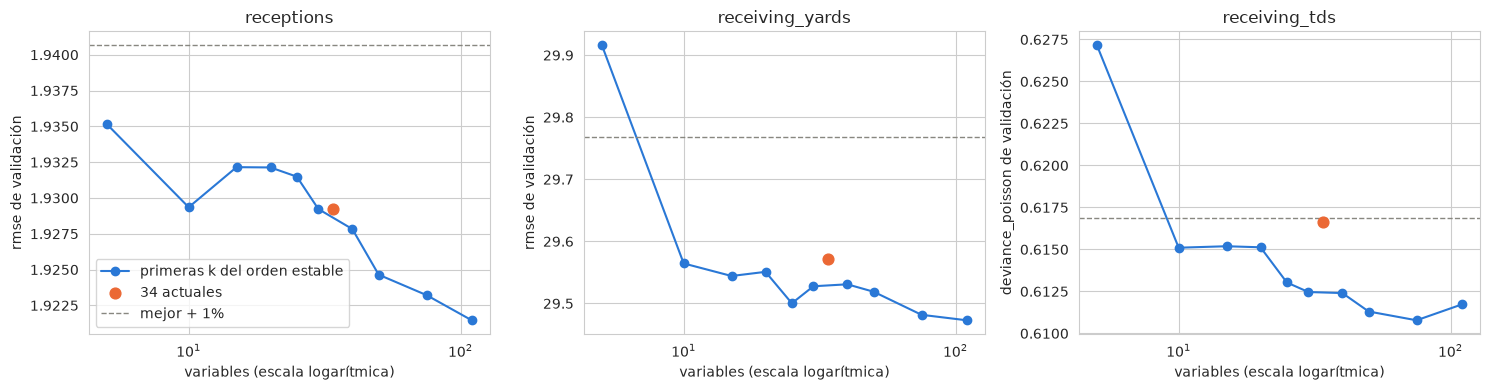

,conjunto,target,perdida,mejor,dif_vs_mejor,ic_inf_vs_mejor,ic_sup_vs_mejor,cota_relativa,dif_vs_referencia,ic_inf_vs_referencia,ic_sup_vs_referencia
4,primeras 25,receptions,1.9315,todas,0.0100,0.0036,0.0165,0.0086,0.0022,-0.0052,0.0096
15,primeras 25,receiving_yards,29.5002,todas,0.0274,-0.0646,0.1211,0.0041,-0.0716,-0.1702,0.0282
26,primeras 25,receiving_tds,0.6130,primeras 75,0.0023,-0.0010,0.0055,0.0090,-0.0036,-0.0085,0.0012


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TARGETS):
    datos = tabla_eleccion[tabla_eleccion["target"] == t]
    curva = datos[datos["conjunto"] != "34 actuales"].sort_values("variables")
    ax.plot(curva["variables"], curva["perdida"], marker="o", color=AZUL, label="primeras k del orden estable")
    vigente = datos[datos["conjunto"] == "34 actuales"]
    ax.scatter(vigente["variables"], vigente["perdida"], color=NARANJA, s=60, zorder=5, label="34 actuales")
    margen = datos["perdida"].min() * 1.01
    ax.axhline(margen, color=GRIS, linestyle="--", linewidth=1, label="mejor + 1%")
    ax.set_xscale("log")
    ax.set_title(t)
    ax.set_xlabel("variables (escala logarítmica)")
    ax.set_ylabel(f"{modeling.METRICA_PRINCIPAL[t]} de validación")
axes[0].legend()
plt.tight_layout()
plt.show()

columnas_detalle = ["conjunto", "target", "perdida", "mejor", "dif_vs_mejor", "ic_inf_vs_mejor", "ic_sup_vs_mejor",
                    "cota_relativa", "dif_vs_referencia", "ic_inf_vs_referencia", "ic_sup_vs_referencia"]
tabla_eleccion[tabla_eleccion["conjunto"] == elegido][columnas_detalle].round(4)

**Lectura.** El mejor conjunto en validación es usar todas las candidatas en recepciones y yardas, y
las 75 primeras en touchdowns, pero las diferencias son chicas: con 25 variables la pérdida queda
como mucho a 0.86% del mejor en recepciones, 0.41% en yardas y 0.90% en touchdowns (cotas superiores
de los intervalos de 95%), dentro del margen de 1% en los tres. Es el conjunto más chico que lo
cumple. Lo que deja fuera a los conjuntos más chicos es sobre todo touchdowns: con 10, 15 o 20
variables la cota es de 1.55%, 1.45% y 1.38%. Las 34 actuales tampoco cumplen el margen (1.69% en
touchdowns).

La línea punteada de la gráfica marca el mejor más 1%, pero la regla no compara el punto sino la
cota superior del intervalo, que es más exigente.

Contra las 34 actuales, las 25 empatan en los tres resultados en validación: +0.0022 de RMSE en
recepciones (intervalo de −0.0052 a +0.0096), −0.0716 en yardas (de −0.1702 a +0.0282) y −0.0036
de deviance en touchdowns (de −0.0085 a +0.0012).

## 5. El conjunto elegido

In [8]:
DESCRIPCION_BASE = {
    "receptions": "recepciones", "targets": "objetivos (pases que le lanzaron)",
    "receiving_yards": "yardas de recepción", "receiving_air_yards": "yardas aéreas de sus objetivos",
    "receiving_yards_after_catch": "yardas tras la recepción", "receiving_first_downs": "primeros downs por recepción",
    "receiving_tds": "touchdowns de recepción", "receiving_2pt_conversions": "conversiones de 2 puntos",
    "receiving_10": "recepciones de 10 o más yardas", "receiving_16": "recepciones de 16 o más yardas",
    "receiving_20": "recepciones de 20 o más yardas", "receiving_40": "recepciones de 40 o más yardas",
    "target_share": "participación en los objetivos del equipo",
    "air_yards_share": "participación en las yardas aéreas del equipo", "wopr": "índice de oportunidad (wopr)",
    "receiving_epa": "puntos esperados agregados como objetivo (EPA)", "fantasy_points_ppr": "puntos de fantasy PPR",
    "yards_per_target": "yardas por objetivo", "catch_rate": "fracción de objetivos atrapados",
    "air_yards_per_target": "yardas aéreas por objetivo", "racr_acotado": "yardas entre yardas aéreas (racr, con tope)",
}
VENTANA = {"_season_avg": "promedio de la temporada", "_last3_avg": "promedio de sus últimas 3 apariciones",
           "_last5_avg": "promedio de sus últimas 5 apariciones", "_career_avg": "promedio de carrera"}
CONTEXTO = {
    "receiving_yards_volatilidad5": "desviación estándar de sus yardas en sus últimas 5 apariciones",
    "targets_volatilidad5": "desviación estándar de sus objetivos en sus últimas 5 apariciones",
    "edad": "edad al 1 de septiembre de la temporada", "anios_experiencia": "temporadas en la NFL (0 = novato)",
    "anios_experiencia_sq": "temporadas en la NFL, al cuadrado", "anios_experiencia_bucket": "experiencia por tramos",
    "draft_pick": "número de selección en el draft (más bajo = elegido antes)",
    "rest": "días de descanso de su equipo antes del partido", "div_game": "1 si el rival es de su división",
    "roof": "techo del estadio", "surface": "superficie del campo",
    "depth_team": "lugar en la alineación de su equipo (1 = titular)",
    "total_implicito_equipo": "puntos que las líneas de apuestas esperan que anote su equipo",
    "cambio_qb_titular_num": "1 si cambió el quarterback titular de su equipo", "cambio_equipo_num": "1 si cambió de equipo",
    "target_share_x_ofensiva_equipo": "participación reciente por yardas de recepción de su equipo",
    "draft_pick_x_experiencia": "número de draft por temporadas en la NFL",
    "cambio_qb_x_target_share": "cambio de quarterback por participación reciente",
}

def que_es(variable):
    if variable in CONTEXTO:
        return CONTEXTO[variable]
    for sufijo, ventana in VENTANA.items():
        if variable.endswith(sufijo):
            base = variable[: -len(sufijo)]
            if base.startswith("equipo_"):
                return f"{DESCRIPCION_BASE[base[len('equipo_'):]]} de los WR de su equipo: {ventana}"
            return f"{DESCRIPCION_BASE[base]}: {ventana}"
    return ""

elegidas = conjuntos[elegido]
tabla_final = pd.DataFrame({
    "variable": elegidas,
    "qué es": [que_es(v) for v in elegidas],
    "ronda promedio de salida": orden.reindex(elegidas)["ronda_promedio"].round(1).to_numpy(),
    "en las 34 actuales": ["sí" if v in actuales else "no" for v in elegidas],
})
entran = [v for v in elegidas if v not in actuales]
salen = [v for v in actuales if v not in elegidas]
print(f"entran ({len(entran)}): {', '.join(entran) if entran else 'ninguna'}")
print(f"salen ({len(salen)}): {', '.join(salen) if salen else 'ninguna'}")
tabla_final

entran (8): total_implicito_equipo, receiving_yards_after_catch_career_avg, target_share_season_avg, receiving_yards_last5_avg, fantasy_points_ppr_career_avg, wopr_season_avg, target_share_x_ofensiva_equipo, receiving_yards_after_catch_season_avg
salen (17): air_yards_share_career_avg, air_yards_share_season_avg, anios_experiencia, catch_rate_career_avg, fantasy_points_ppr_season_avg, receiving_10_last3_avg, receiving_16_last5_avg, receiving_20_last3_avg, receiving_air_yards_season_avg, receiving_epa_last3_avg, receiving_first_downs_last5_avg, receiving_tds_season_avg, receiving_yards_last3_avg, receiving_yards_season_avg, target_share_career_avg, targets_last3_avg, wopr_last5_avg


,variable,qué es,ronda promedio de salida,en las 34 actuales
0,receptions_career_avg,recepciones: promedio de carrera,26.6,sí
1,depth_team,lugar en la alineación de su equipo (1 = titular),22.3,sí
2,target_share_last5_avg,participación en los objetivos del equipo: promedio de sus últimas 5 apariciones,22.2,sí
3,receptions_season_avg,recepciones: promedio de la temporada,21.6,sí
4,target_share_last3_avg,participación en los objetivos del equipo: promedio de sus últimas 3 apariciones,21.3,sí
5,receptions_last3_avg,recepciones: promedio de sus últimas 3 apariciones,20.6,sí
6,fantasy_points_ppr_last5_avg,puntos de fantasy PPR: promedio de sus últimas 5 apariciones,19.0,sí
7,total_implicito_equipo,puntos que las líneas de apuestas esperan que anote su equipo,18.9,no
8,receiving_yards_after_catch_career_avg,yardas tras la recepción: promedio de carrera,17.7,no
9,receiving_yards_career_avg,yardas de recepción: promedio de carrera,17.7,sí


**Lectura.** De las 34 variables actuales se quedan 17 y entran 8: el total implícito, las yardas
tras la recepción (de carrera y de la temporada), `target_share` de la temporada, las yardas de sus
últimas 5 apariciones, los puntos de fantasy de carrera, `wopr` de la temporada y la interacción de
participación con la ofensiva del equipo. Salen 17, entre ellas los dos promedios de
`air_yards_share` que no son de las últimas 3 apariciones, las jugadas de 10, 16 y 20 yardas o más, el
EPA, la tasa de atrapadas, los touchdowns de la temporada y la experiencia (la edad se queda).

## 6. Prueba 2024-2025, solo como reporte

La prueba no decide nada. Se reportan el conjunto elegido, el de 10 variables que elegía la primera
versión de la regla y las 34 actuales, con la diferencia contra las 34 y su intervalo de 95%.

In [9]:
filas = {}
for nombre in dict.fromkeys([elegido, "primeras 10", "34 actuales"]):
    for t in TARGETS:
        m = modeling.metricas_target(t, ys[t][test_mask], predicciones[nombre][t][test_mask], ys[t][train_mask].mean())
        fila = {k: m.get(k) for k in ("rmse", "deviance_poisson", "r2_oos", "d2_oos", "pendiente_calibracion")}
        if nombre != "34 actuales":
            c = experimentos.diferencia_bootstrap(wr[test_mask], ys[t][test_mask], predicciones[nombre][t][test_mask],
                                                  predicciones["34 actuales"][t][test_mask], modeling.METRICA_PRINCIPAL[t])
            fila.update({"dif_vs_34": c["diferencia"], "ic_inf": c["ic_inferior"], "ic_sup": c["ic_superior"]})
        filas[(nombre, t)] = fila
pd.DataFrame(filas).T.astype(float).round(4)

rmse  deviance_poisson  r2_oos  d2_oos  pendiente_calibracion  dif_vs_34  ic_inf  ic_sup
primeras 25 receptions        1.8355            1.3980  0.4527  0.4493                 1.0212     0.0097  0.0044  0.0151
            receiving_yards  27.9349               NaN  0.3744     NaN                 1.0159     0.0206 -0.0864  0.1316
            receiving_tds     0.4457            0.6222  0.0902  0.1398                 1.0363    -0.0030 -0.0075  0.0015
primeras 10 receptions        1.8335            1.3988  0.4540  0.4490                 1.0182     0.0076  0.0008  0.0144
            receiving_yards  27.9634               NaN  0.3731     NaN                 1.0053     0.0491 -0.0841  0.1822
            receiving_tds     0.4466            0.6273  0.0864  0.1327                 1.0248     0.0021 -0.0043  0.0080
34 actuales receptions        1.8258            1.3913  0.4585  0.4520                 1.0245        NaN     NaN     NaN
            receiving_yards  27.9143               NaN  0.3754     NaN                 1.0300        NaN     NaN     NaN
            receiving_tds     0.4463            0.6252  0.0877  0.1355                 1.0104        NaN     NaN     NaN

**Lectura.** En la prueba, las 25 variables quedan peor que las 34 en recepciones (+0.0097 de RMSE,
intervalo de +0.0044 a +0.0151), empatan en yardas (+0.0206, de −0.0864 a +0.1316) y en touchdowns
(−0.0030 de deviance, de −0.0075 a +0.0015). El conjunto de 10 de la primera regla también quedaba
peor en recepciones (+0.0076, de +0.0008 a +0.0144).

Esta comparación no es pareja: las 34 se eligieron en `3.2` midiendo la importancia en 2024-2025, los
mismos años de esta prueba, así que su resultado aquí es optimista; en validación 2022-2023, que
ninguno de los dos conjuntos usó para elegir, empatan. Lo que no se puede saber con la prueba es
cuánto de la diferencia en recepciones viene de eso. La comparación limpia entre ambos conjuntos es la
temporada 2026, que ninguno usó.

## Cierre

- **25 variables**, elegidas con la regla de no inferioridad del ADR 0005: el conjunto más chico que,
  con 95% de confianza, no es más de 1% peor que el mejor en validación en ninguno de los tres
  resultados. Reemplazan a las 34 de `3.2`, que se habían elegido con MAE y con los años de prueba.
- **El total implícito de las líneas de apuestas entra**, en el octavo lugar del orden estable.
- **La primera regla para elegir el tamaño se corrigió**: tomaba un empate como prueba de que un
  conjunto no era peor. El problema se vio al reportar la prueba; la corrección se aplica solo en
  validación ([`docs/HALLAZGOS.md`](../../../docs/HALLAZGOS.md)).
- **En la prueba, las 34 quedan mejor en recepciones**, pero esa comparación favorece a las 34, que se
  eligieron con esos mismos años. La temporada 2026 es la verificación limpia.

El conjunto pasa a `features.py` y las etapas 4 a 6 se vuelven a ejecutar con él.

Anterior: [`3.2_seleccion_features.ipynb`](3.2_seleccion_features.ipynb) · Siguiente:
[`4.1_preparacion_y_metricas.ipynb`](4.1_preparacion_y_metricas.ipynb)